In [1]:
#### Other libraries
import sys
import os

import ast
from collections import Counter

import re
import nltk

In [2]:
#### Pandas set-up
import numpy as np
import pandas as pd

In [3]:
#### Visualization
sys.path.append('/Users/debr/English-Homer') 
import matplotlib.pyplot as plt
import seaborn as sns
import bard_visualization as viz # My Vizualization library

Bard viz is on the stage!


In [4]:
# Import my functions
sys.path.append('/Users/debr/English-Homer/functions') 
import e_nlp as e

e enters! »----> use e.<function>

e.g., for pipeline:
		 nlp = e.NLPPipeline(language="english")

Stopwords customized:
  Added: {"'", 'three', 'two', 'five', 'four', 'ten', 'eight', "'and", 'seven', 'nine', 'n', 'six', 'one'}
  Removed: {''}
  Total stopwords: 211
Punctuation customized:
  Keeping: {'', '-'}
  Additional removals: {'\\', '“', '”', '’', '-', '—', '‘', '…'}
  Punctuation to be removed: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~—‘’“”…


[nltk_data] Downloading package punkt_tab to /Users/debr/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [6]:
etymologypath = '/Users/debr/odysseys_en/word_ety_odysseys.tsv'
etymology_df = pd.read_csv(etymologypath, sep="\t", names=["word", "etymology"], encoding="utf-8")
etymology_df.sample(10, random_state=42)

,word,etymology
12507,scopes,['eng: scopes']
1119,bat,['fro: bast']
15537,underrate,['eng: under-']
16693,woodpile,['ang: wudu']
13855,stain,['enm: steinen']
361,aldermen,['eng: aldermen']
14676,tease,['ang: tæsan']
12949,shifts,['eng: shifts']
123,acquiring,['eng: acquiring']
2420,chimneys,['eng: chimneys']


In [32]:
etymology_df['ety_label'] = etymology_df['etymology'].str.extract(r"\['(\w{3})").astype("category")

In [33]:
print(etymology_df['ety_label'].sample(5, random_state=24))

6578     eng
8739     eng
5563     ang
10634    eng
6128     lat
Name: ety_label, dtype: category
Categories (44, object): ['afr', 'ang', 'ara', 'arg', ..., 'sux', 'tnq', 'tur', 'xno']


In [43]:
filepath = '/Users/debr/odysseys_en/Odyssey_Six_Modern.csv'
# Creating df and specific columns
odysseys_df = pd.read_csv(filepath, sep=",", encoding="utf-8")
odysseys_df = odysseys_df[['translator', 'book_num', 'tokens']]
odysseys_df['translator'] = odysseys_df['translator'].astype("category")
odysseys_df['tokens'] = odysseys_df['tokens'].apply(ast.literal_eval)
e.check_df(odysseys_df)

Oh, yeah! No missing values here!

* df columns: Index(['translator', 'book_num', 'tokens'], dtype='object') 

* Shape: (144, 3) 

* Total memory in MB: 2.860675


In [44]:
print(odysseys_df.memory_usage(deep=True)       / 1_000_000)
print(odysseys_df.memory_usage(deep=True).sum() / 1_000_000)

Index         0.000132
translator    0.000703
book_num      0.001152
tokens        2.858688
dtype: float64
2.860675


In [45]:
print(etymology_df.memory_usage(deep=True)       / 1_000_000)
print(etymology_df.memory_usage(deep=True).sum() / 1_000_000)

Index        0.000132
word         1.089155
etymology    1.256410
ety_label    0.020593
dtype: float64
2.36629


In [39]:
e.check_df(etymology_df)

Missing values in word
Missing values in ety_label

* df columns: Index(['word', 'etymology', 'ety_label'], dtype='object') 

* Shape: (16881, 3) 

* Total memory in MB: 2.36629


In [56]:
# Explode tokens column to have one word per row
odyssey_exploded = odysseys_df.explode("tokens")

# Merge with etymology_df to get ety_label
odyssey_exploded = odyssey_exploded\
                            .merge(etymology_df[['word', 'ety_label']], left_on='tokens', right_on='word', how='left')

# Group back by translator and book_num to form lists of ety_labels
odysseys_df['ety_labels'] = odyssey_exploded\
                            .groupby(['translator', 'book_num'],
                                      observed=True)['ety_label']\
                                    .apply(list).reset_index(drop=True)

odysseys_df.head(10)

,translator,book_num,tokens,ety_labels
0,AT_Murray,1,"[tell, muse, manysided, hero, traveled, far, w...","[ang, grc, eng, eng, eng, ang, enm, eng, fro, ..."
1,AT_Murray,2,"[child, morning, rosyfingered, dawn, appeared,...","[eng, enm, eng, eng, eng, eng, fra, eng, lat, ..."
2,AT_Murray,3,"[sun, rising, fair, sea, firmament, heaven, sh...","[ang, eng, lat, ang, eng, ang, enm, enm, eng, ..."
3,AT_Murray,4,"[reached, low, lying, city, lacedaemon, drove,...","[eng, ang, ang, lat, eng, eng, enm, eng, eng, ..."
4,AT_Murray,5,"[dawn, rose, couch, beside, tithonos, harbinge...","[eng, fra, lat, eng, eng, eng, enm, ang, eng, ..."
5,AT_Murray,6,"[odysseus, slept, overcome, sleep, toil, athen...","[eng, eng, ang, ang, enm, eng, eng, grc, lat, ..."
6,AT_Murray,7,"[thus, odysseus, wait, pray, girl, drove, town...","[enm, eng, enm, fro, eng, eng, eng, eng, ang, ..."
7,AT_Murray,8,"[child, morning, rosyfingered, dawn, appeared,...","[eng, enm, eng, eng, eng, eng, eng, fra, eng, ..."
8,AT_Murray,9,"[odysseus, answered, king, alkinoos, good, thi...","[eng, eng, enm, eng, enm, eng, ang, fra, lat, ..."
9,AT_Murray,10,"[thence, went, aeolian, island, lives, aeolus,...","[eng, eng, eng, eng, eng, eng, enm, eng, ang, ..."


In [59]:
from collections import Counter

odysseys_df['ety_label_counts'] = odysseys_df['ety_labels'].apply(lambda x: dict(Counter(x)))
odysseys_df['ety_label_counts'][0]

{'ang': 459,
 'grc': 12,
 'eng': 804,
 'enm': 294,
 'fro': 45,
 'lat': 113,
 'xno': 20,
 'non': 25,
 'heb': 7,
 'fra': 12,
 'p_g': 3,
 'ita': 2,
 'tur': 1,
 'msa': 1,
 'gml': 1,
 'spa': 1}

In [78]:
at_murray = odysseys_df[odysseys_df['translator'] == 'AT_Murray']
#at_murray_count = at_murray['ety_label_counts'].sum()
e.check_df(at_murray)

Oh, yeah! No missing values here!

* df columns: Index(['translator', 'book_num', 'tokens', 'ety_labels', 'ety_label_counts'], dtype='object') 

* Shape: (24, 5) 

* Total memory in MB: 0.863103


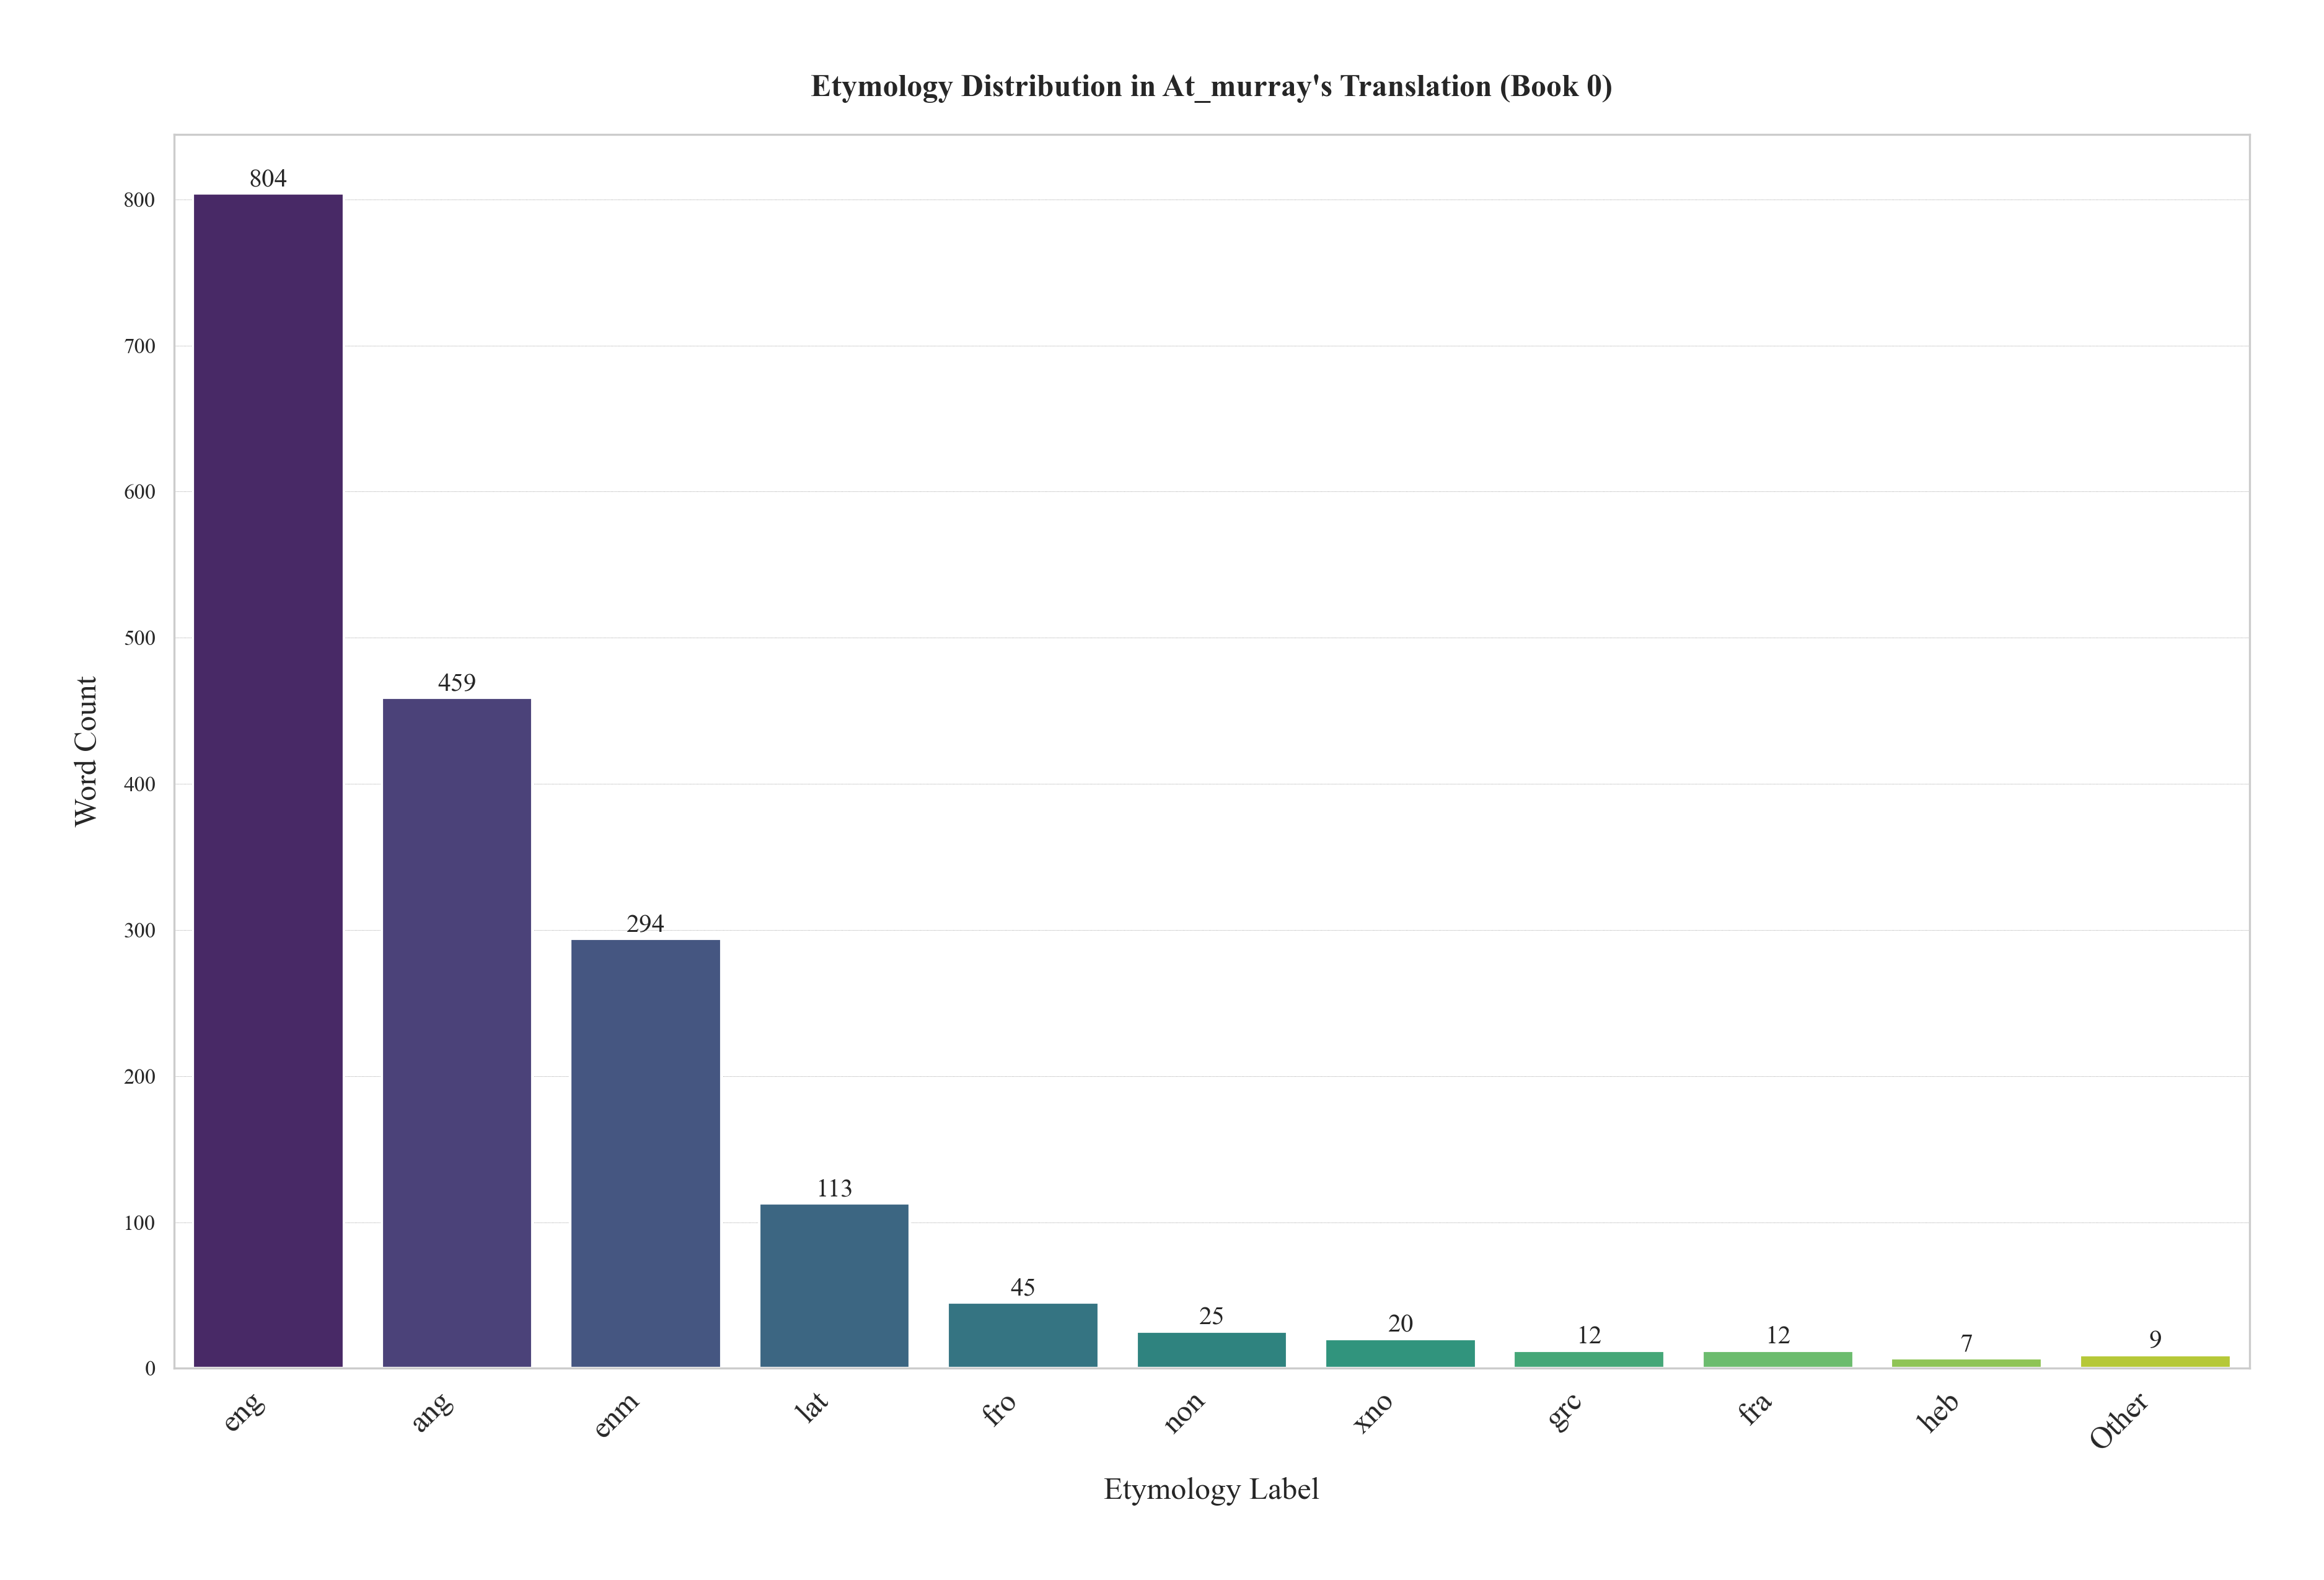

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is already loaded with your data
# This code will extract and plot the etymology counts for Murray's translation

def plot_etymology_counts(df, translator_name='murray', book_num=0, top_n=10):
    """
    Plot the etymology label counts for a specific translator and book.
    
    Parameters:
    df (DataFrame): The DataFrame containing the data
    translator_name (str): The name of the translator to filter by
    book_num (int): The book number to filter by
    top_n (int): Number of top etymologies to display
    """
    # Filter for the specific translator
    translator_data = df[df['translator'] == translator_name]
    
    # Get the etymology counts for the specified book
    if book_num in translator_data.index:
        ety_counts = translator_data.loc[book_num, 'ety_label_counts']
    else:
        # If book_num is not an index, try filtering by the book_num column
        book_data = translator_data[translator_data['book_num'] == book_num]
        if len(book_data) == 0:
            print(f"No data found for translator {translator_name}, book {book_num}")
            return
        ety_counts = book_data.iloc[0]['ety_label_counts']
    
    # Convert dictionary to a DataFrame for easier plotting
    ety_df = pd.DataFrame(list(ety_counts.items()), columns=['Etymology', 'Count'])
    
    # Sort by count in descending order
    ety_df = ety_df.sort_values('Count', ascending=False)
    
    # Take top N etymologies
    if len(ety_df) > top_n:
        other_count = ety_df.iloc[top_n:]['Count'].sum()
        ety_df = ety_df.iloc[:top_n]
        ety_df = pd.concat([ety_df, pd.DataFrame([['Other', other_count]], columns=['Etymology', 'Count'])])
    
    # Create the plot
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Etymology', y='Count', data=ety_df, palette='viridis')
    
    # Customize the plot
    plt.title(f'Etymology Distribution in {translator_name.capitalize()}\'s Translation (Book {book_num})')
    plt.xlabel('Etymology Label')
    plt.ylabel('Word Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # Add count labels on top of bars
    for i, v in enumerate(ety_df['Count']):
        plt.text(i, v + 5, str(v), ha='center')
    
    plt.show()

# Example usage:
# Assuming 'murray' is the correct identifier in your DataFrame
plot_etymology_counts(at_murray, translator_name='AT_Murray', book_num=0, top_n=10)

# If you need to see what translator values are available:
# print(df['translator'].unique())

# For a more comprehensive view, you could also plot all books for a translator:
def plot_all_books_etymology(df, translator_name='murray', top_etymologies=5):
    """Plot the top etymologies across all books for a specific translator"""
    translator_data = df[df['translator'] == translator_name]
    
    # Create a figure with subplots
    n_books = len(translator_data)
    fig, axes = plt.subplots(n_books, 1, figsize=(12, 4*n_books))
    
    # If there's only one book, axes won't be an array
    if n_books == 1:
        axes = [axes]
    
    for i, (idx, row) in enumerate(translator_data.iterrows()):
        ety_counts = row['ety_label_counts']
        book_num = row['book_num']
        
        # Convert to DataFrame, sort, and take top N
        ety_df = pd.DataFrame(list(ety_counts.items()), columns=['Etymology', 'Count'])
        ety_df = ety_df.sort_values('Count', ascending=False)
        ety_df = ety_df.head(top_etymologies)
        
        # Plot
        sns.barplot(x='Etymology', y='Count', data=ety_df, ax=axes[i])
        axes[i].set_title(f'Book {book_num}: Top {top_etymologies} Etymologies')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.suptitle(f'Etymology Distribution in {translator_name.capitalize()}\'s Translation', y=1.02, fontsize=16)
    plt.show()

# Example usage:
#plot_all_books_etymology(at_murray, translator_name='AT_Murray')

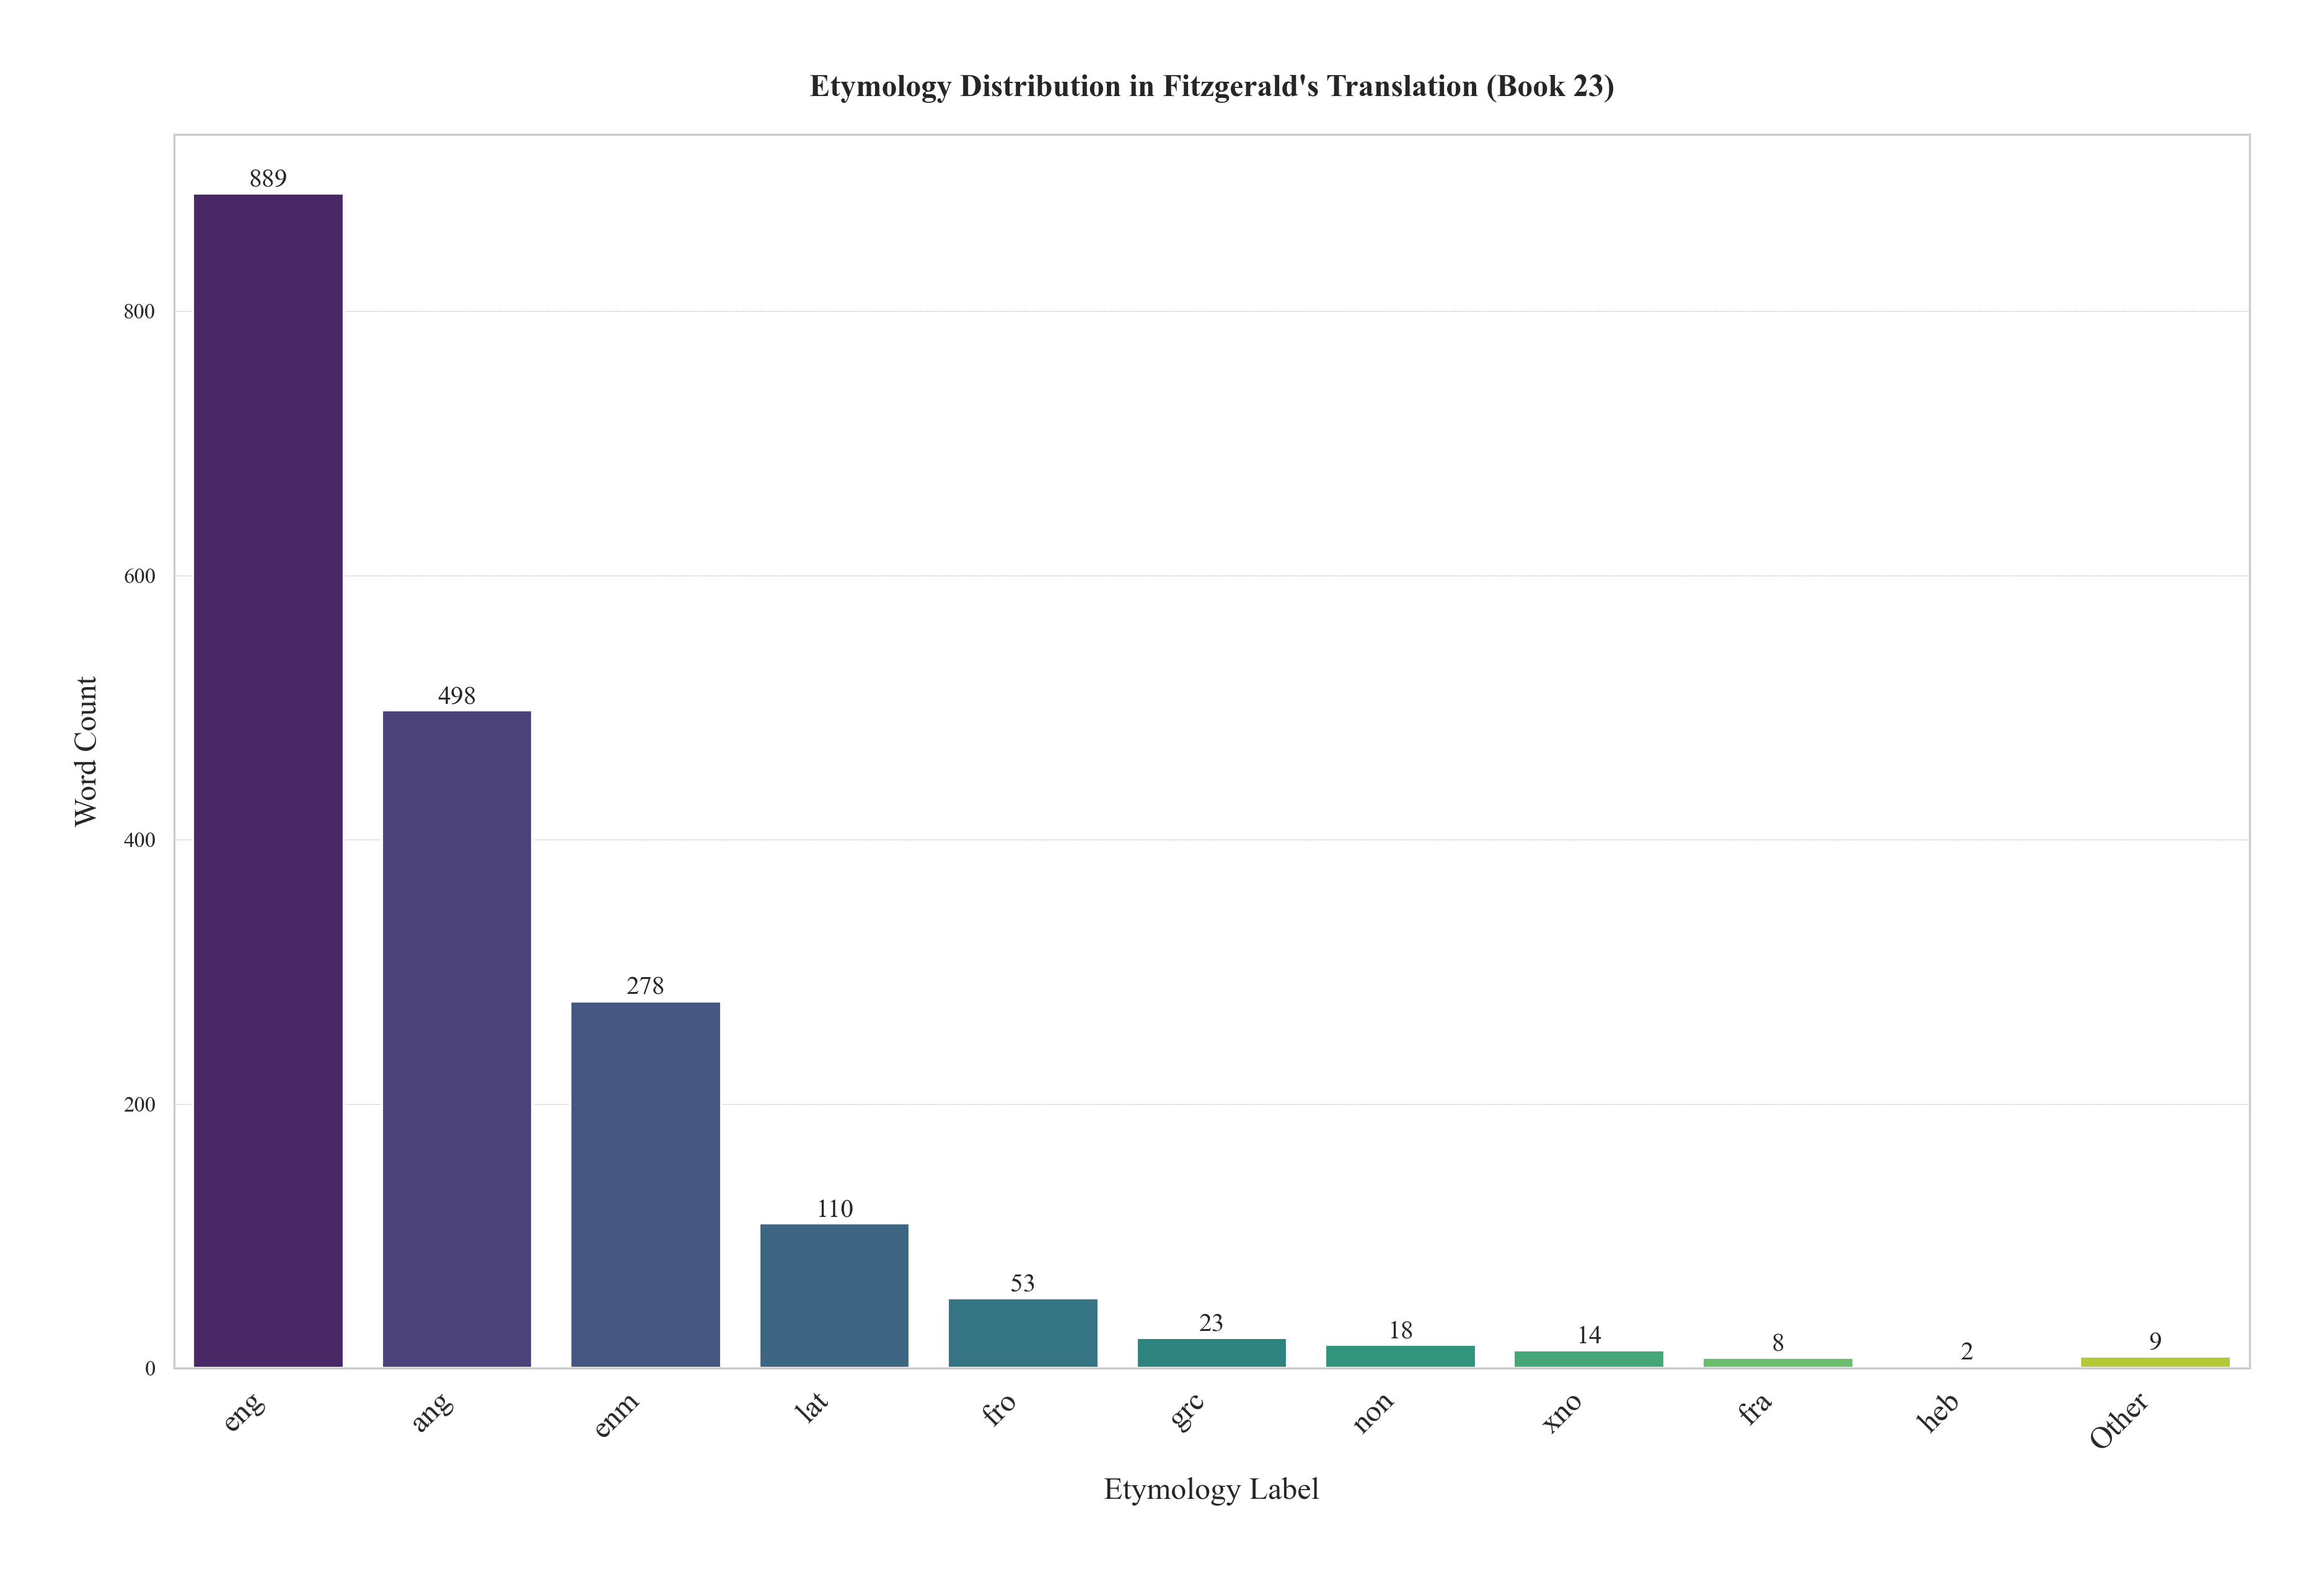

In [88]:
Fitzgerald = odysseys_df[odysseys_df['translator'] == 'Fitzgerald']
plot_etymology_counts(Fitzgerald, translator_name='Fitzgerald', book_num=23, top_n=10)

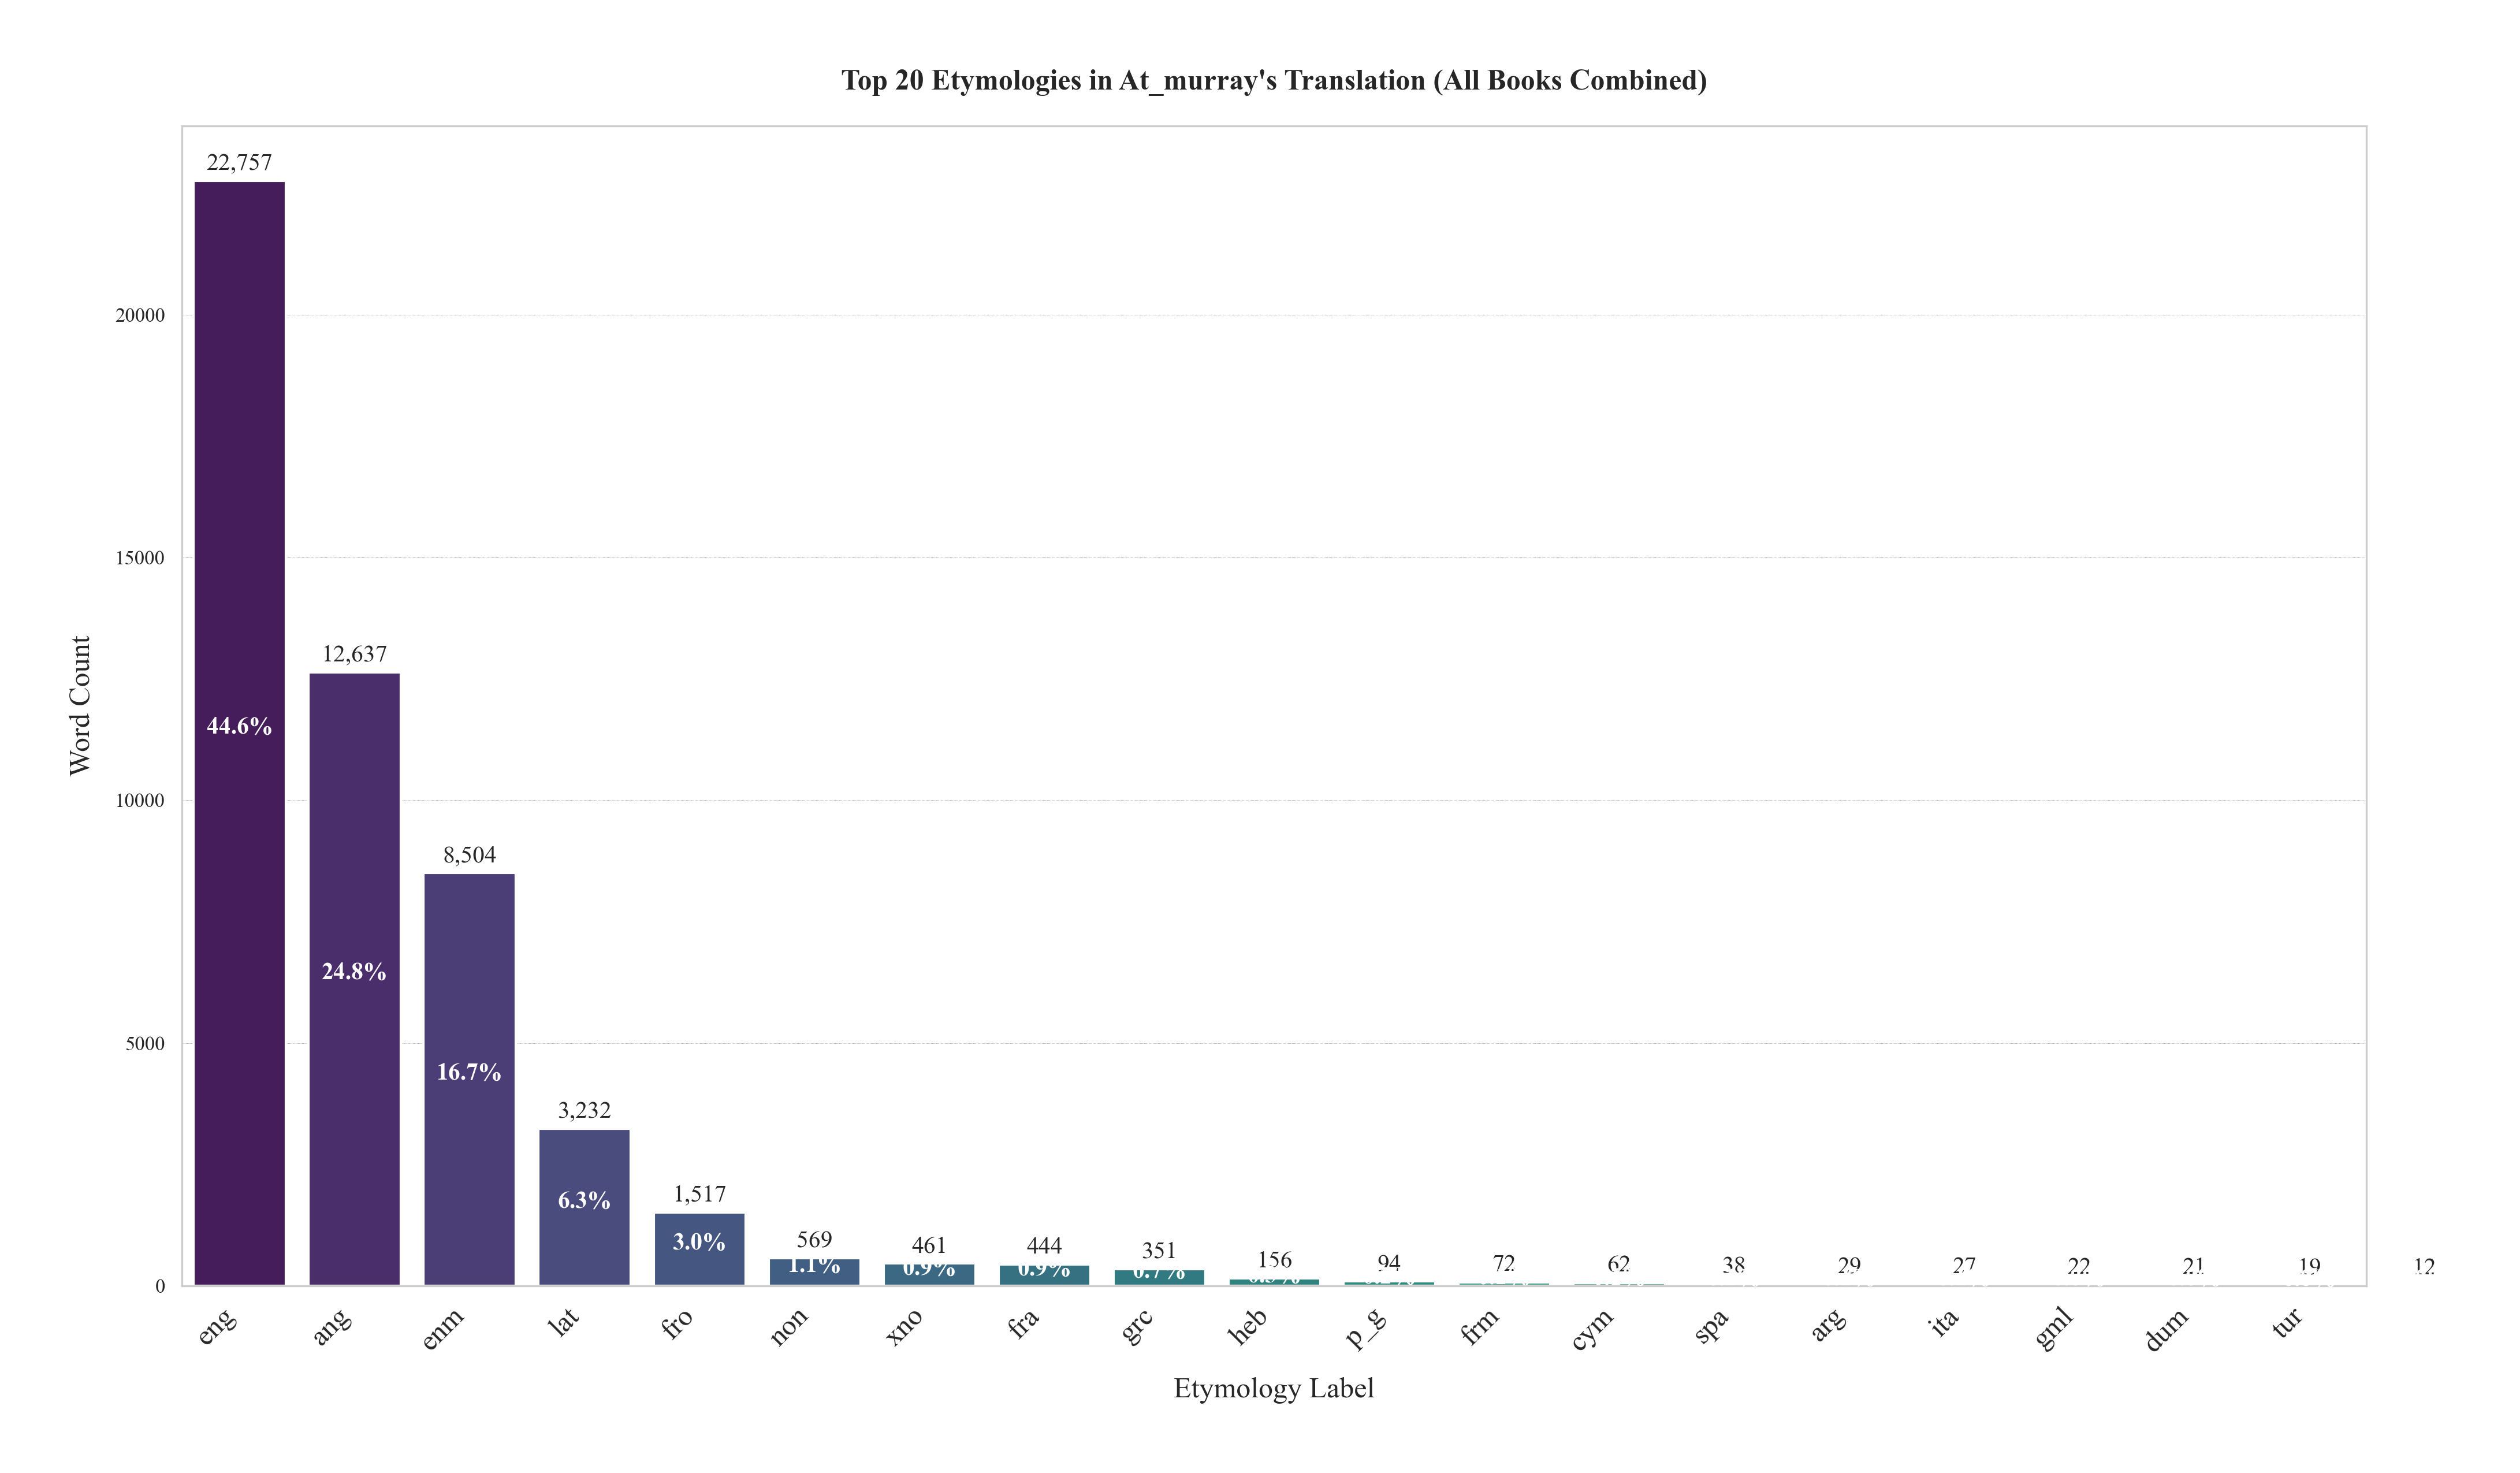

Total words analyzed: 51,073
Number of distinct etymologies: 33
Percentage of words from top 3 etymologies: 85.95%


In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def plot_aggregated_etymologies(df, translator_name='murray', top_n=20):
    """
    Aggregate etymology counts across all books for a specific translator
    and plot the top N most frequent etymologies.
    
    Parameters:
    df (DataFrame): The DataFrame containing the data
    translator_name (str): The name of the translator to filter by
    top_n (int): Number of top etymologies to display
    """
    # Filter for the specific translator
    translator_data = df[df['translator'] == translator_name]
    
    if len(translator_data) == 0:
        print(f"No data found for translator: {translator_name}")
        print(f"Available translators: {df['translator'].unique()}")
        return
    
    # Aggregate counts across all books
    aggregated_counts = Counter()
    
    for _, row in translator_data.iterrows():
        ety_counts = row['ety_label_counts']
        aggregated_counts.update(ety_counts)
    
    # Convert the aggregated counter to a DataFrame
    agg_df = pd.DataFrame(list(aggregated_counts.items()), columns=['Etymology', 'Count'])
    
    # Sort by count in descending order and get top N
    agg_df = agg_df.sort_values('Count', ascending=False).head(top_n)
    
    # Create the plot
    plt.figure(figsize=(14, 8))
    bar_plot = sns.barplot(x='Etymology', y='Count', data=agg_df, palette='viridis')
    
    # Customize the plot
    plt.title(f'Top {top_n} Etymologies in {translator_name.capitalize()}\'s Translation (All Books Combined)')
    plt.xlabel('Etymology Label')
    plt.ylabel('Word Count')
    plt.xticks(rotation=45, ha='right')
    
    # Add count labels on top of bars
    for i, v in enumerate(agg_df['Count']):
        plt.text(i, v + (max(agg_df['Count']) * 0.01), f'{v:,}', ha='center')
    
    # Add percentage labels
    total_words = agg_df['Count'].sum()
    for i, v in enumerate(agg_df['Count']):
        percentage = (v / total_words) * 100
        plt.text(i, v/2, f'{percentage:.1f}%', ha='center', color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return aggregated_counts

# Example usage
aggregated_counts = plot_aggregated_etymologies(at_murray, translator_name='AT_Murray', top_n=20)

# Optional: Print the total number of words analyzed
if aggregated_counts:
    total_words = sum(aggregated_counts.values())
    print(f"Total words analyzed: {total_words:,}")
    
    # Calculate and display etymology diversity metrics
    print(f"Number of distinct etymologies: {len(aggregated_counts)}")
    
    # Calculate percentage of words from the top 3 etymologies
    top_3 = sum(count for _, count in aggregated_counts.most_common(3))
    print(f"Percentage of words from top 3 etymologies: {(top_3/total_words)*100:.2f}%")